In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from tqdm import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')
# # === Dataset Paths ===
BASE_DIR = r"D:\tugas\skripsi\Deam_Dataset"
AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
                         "annotations averaged per song", "song_level")

# --- Load annotation CSVs ---
annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")

df1 = pd.read_csv(annot_file_1)
df2 = pd.read_csv(annot_file_2)

# Standardize column names (strip whitespace)
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

print(f"Annotations file 1 shape: {df1.shape}")
print(f"Annotations file 2 shape: {df2.shape}")
print(f"\nFile 1 columns: {list(df1.columns)}")
print(f"File 2 columns: {list(df2.columns)}")
print(f"\nFile 1 sample:")
df1.head()

# # Import library yang dibutuhkan
# import os
# import pandas as pd

# # Sambungkan Google Colab dengan Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# # === Dataset Paths ===
# # Menggunakan path Google Drive yang baru
# BASE_DIR = "/content/drive/MyDrive/DEAM_Dataset"
# AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
# ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
#                          "annotations averaged per song", "song_level")

# # --- Load annotation CSVs ---
# annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
# annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")

# df1 = pd.read_csv(annot_file_1)
# df2 = pd.read_csv(annot_file_2)

# # Standardize column names (strip whitespace)
# df1.columns = df1.columns.str.strip()
# df2.columns = df2.columns.str.strip()

# print(f"Annotations file 1 shape: {df1.shape}")
# print(f"Annotations file 2 shape: {df2.shape}")
# print(f"\nFile 1 columns: {list(df1.columns)}")
# print(f"File 2 columns: {list(df2.columns)}")
# print(f"\nFile 1 sample:")
# df1.head()

# === Dataset Paths ===
# Using the native Linux path since we are running in WSL
# BASE_DIR = "/home/beingyou/music_emotion_project/DEAM_Dataset"
# AUDIO_DIR = os.path.join(BASE_DIR, "DEAM_audio", "MEMD_audio")
# ANNOT_DIR = os.path.join(BASE_DIR, "DEAM_Annotations", "annotations",
#                          "annotations averaged per song", "song_level")
#
# # --- Load annotation CSVs ---
# annot_file_1 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_1_2000.csv")
# annot_file_2 = os.path.join(ANNOT_DIR, "static_annotations_averaged_songs_2000_2058.csv")
#
# df1 = pd.read_csv(annot_file_1)
# df2 = pd.read_csv(annot_file_2)
#
# # Standardize column names (strip whitespace)
# df1.columns = df1.columns.str.strip()
# df2.columns = df2.columns.str.strip()
#
# print(f"Annotations file 1 shape: {df1.shape}")
# print(f"Annotations file 2 shape: {df2.shape}")
# print(f"\nFile 1 columns: {list(df1.columns)}")
# print(f"File 2 columns: {list(df2.columns)}")
# print(f"\nFile 1 sample:")
# df1.head()

Annotations file 1 shape: (1744, 5)
Annotations file 2 shape: (58, 13)

File 1 columns: ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']
File 2 columns: ['song_id', 'valence_mean', 'valence_std', 'valence_ max_mean', 'valence_max_std', 'valence_min_mean', 'valence_min_std', 'arousal_mean', 'arousal_std', 'arousal_max_mean', 'arousal_max_std', 'arousal_min_mean', 'arousal_min_std']

File 1 sample:


,song_id,valence_mean,valence_std,arousal_mean,arousal_std
0,2,3.1,0.94,3.0,0.63
1,3,3.5,1.75,3.3,1.62
2,4,5.7,1.42,5.5,1.63
3,5,4.4,2.01,5.3,1.85
4,7,5.8,1.47,6.4,1.69


In [3]:
# Select common columns: song_id, valence_mean, arousal_mean
# File 1 has: song_id, valence_mean, valence_std, arousal_mean, arousal_std
# File 2 has more columns — we only need the common ones
common_cols = ['song_id', 'valence_mean', 'valence_std', 'arousal_mean', 'arousal_std']

df1_sel = df1[common_cols].copy()
df2_sel = df2[common_cols].copy()

# Merge both annotation dataframes
annotations = pd.concat([df1_sel, df2_sel], ignore_index=True)
annotations = annotations.drop_duplicates(subset='song_id').reset_index(drop=True)

print(f"Total annotated songs: {len(annotations)}")
print(f"\nMissing values:\n{annotations.isnull().sum()}")
print(f"\n--- Descriptive Statistics ---")
annotations[['valence_mean', 'arousal_mean']].describe()


Total annotated songs: 1802

Missing values:
song_id         0
valence_mean    0
valence_std     0
arousal_mean    0
arousal_std     0
dtype: int64

--- Descriptive Statistics ---


,valence_mean,arousal_mean
count,1802.000000,1802.000000
mean,4.904145,4.814029
std,1.174240,1.282187
min,1.600000,1.600000
25%,4.100000,3.800000
50%,4.900000,4.900000
75%,5.800000,5.800000
max,8.400000,8.100000


Total audio files: 1802
Annotated songs with audio: 1802
Annotated songs without audio: 0

Final dataset size: 1802 songs


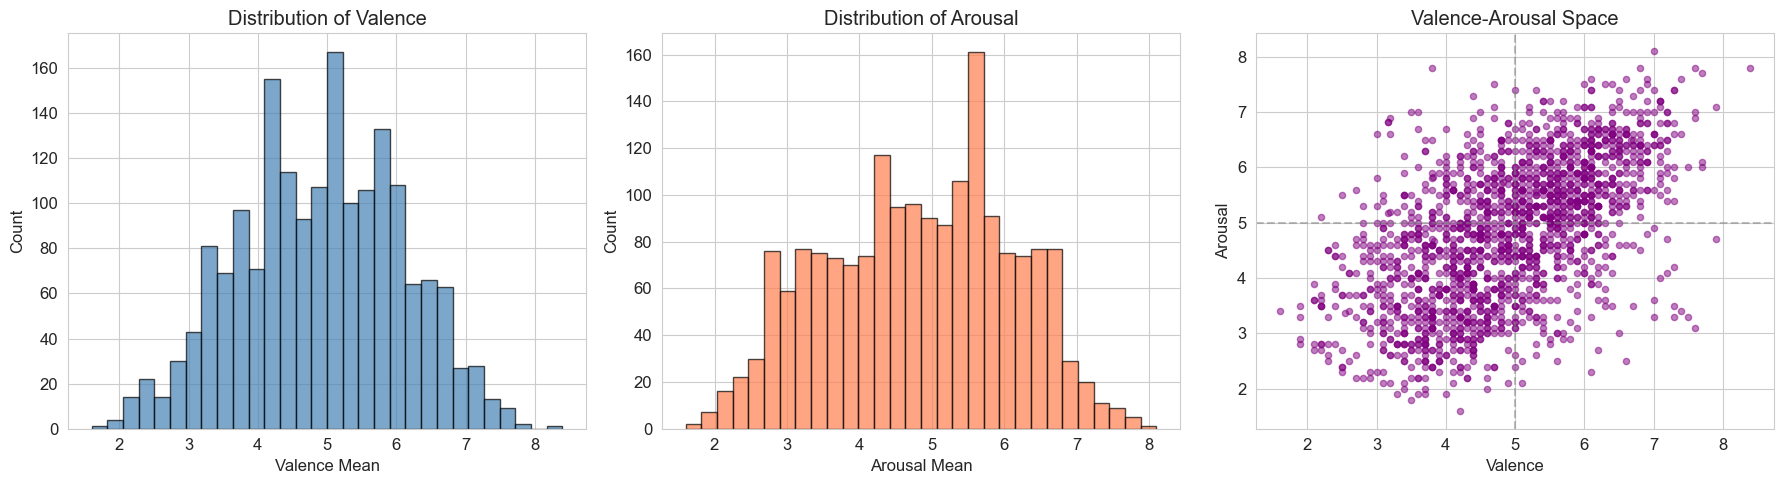

In [4]:
# Check which annotated songs have audio files available
available_audio = set()
for f in os.listdir(AUDIO_DIR):
    if f.endswith('.mp3'):
        song_id = int(os.path.splitext(f)[0])
        available_audio.add(song_id)

annotations['has_audio'] = annotations['song_id'].isin(available_audio)
print(f"Total audio files: {len(available_audio)}")
print(f"Annotated songs with audio: {annotations['has_audio'].sum()}")
print(f"Annotated songs without audio: {(~annotations['has_audio']).sum()}")

# Keep only songs that have audio
annotations = annotations[annotations['has_audio']].drop(columns='has_audio').reset_index(drop=True)
print(f"\nFinal dataset size: {len(annotations)} songs")

# Plot valence-arousal distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(annotations['valence_mean'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Valence Mean')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Valence')

axes[1].hist(annotations['arousal_mean'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Arousal Mean')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Arousal')

axes[2].scatter(annotations['valence_mean'], annotations['arousal_mean'], alpha=0.5, s=20, c='purple')
axes[2].set_xlabel('Valence')
axes[2].set_ylabel('Arousal')
axes[2].set_title('Valence-Arousal Space')
axes[2].axhline(y=5, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
# === Multi-Scale Mel Spectrogram Extraction + Arousal Feature Extraction ===
# 3 different configurations to capture different time-frequency resolutions:
#   Channel 1: Fine frequency (128 mels, hop=512)  — detailed spectral content
#   Channel 2: Coarse frequency (64 mels, hop=256)  — better time resolution
#   Channel 3: Wide frequency (128 mels, hop=1024) — broader temporal context
SR = 22050
DURATION = 45
N_FFT = 2048

MEL_CONFIGS = [
    {"n_mels": 128, "hop_length": 512,  "label": "fine_freq"},
    {"n_mels": 64,  "hop_length": 256,  "label": "fine_time"},
    {"n_mels": 128, "hop_length": 1024, "label": "wide_context"},
]

NUM_AROUSAL_FEATURES = 25  # fixed dimensionality of the arousal feature vector


def extract_arousal_features(y, sr):
    """
    Extract 25 handcrafted arousal-related features from a raw audio signal.

    Features (25 total):
      1  Tempo (BPM)
      2  Rhythmic strength (mean onset strength)
      3-4  RMS energy: mean, std
      5  Dynamic range: max(RMS) - min(RMS)
      6-7  Spectral flux: mean, std (STFT frame-to-frame magnitude diff)
      8-9  Zero crossing rate: mean, std
      10  Harmonic ratio: mean(harmonic_energy / total_energy)
      11  Percussive ratio: mean(percussive_energy / total_energy)
      12-13  Spectral centroid: mean, std
      14-15  Spectral bandwidth: mean, std
      16-17  Spectral rolloff: mean, std
      18-24  Spectral contrast: mean across 7 bands
      25  RMS coefficient of variation (std/mean) — energy volatility
    """
    features = []

    # 1. Tempo (BPM)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    if hasattr(tempo, '__len__'):
        tempo = tempo[0]
    features.append(float(tempo))

    # 2. Rhythmic strength
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    features.append(float(np.mean(onset_env)))

    # 3-4. RMS energy: mean, std
    rms = librosa.feature.rms(y=y)[0]
    features.append(float(np.mean(rms)))
    features.append(float(np.std(rms)))

    # 5. Dynamic range
    features.append(float(np.max(rms) - np.min(rms)))

    # 6-7. Spectral flux (frame-to-frame STFT magnitude difference): mean, std
    S = np.abs(librosa.stft(y))
    spectral_flux = np.sqrt(np.sum(np.diff(S, axis=1) ** 2, axis=0))
    features.append(float(np.mean(spectral_flux)))
    features.append(float(np.std(spectral_flux)))

    # 8-9. Zero crossing rate: mean, std
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    features.append(float(np.mean(zcr)))
    features.append(float(np.std(zcr)))

    # 10-11. Harmonic/Percussive decomposition ratios
    y_harmonic, y_percussive = librosa.effects.hpss(y)
    harmonic_energy = np.mean(y_harmonic ** 2)
    percussive_energy = np.mean(y_percussive ** 2)
    total_energy = harmonic_energy + percussive_energy + 1e-10
    features.append(float(harmonic_energy / total_energy))
    features.append(float(percussive_energy / total_energy))

    # 12-13. Spectral centroid: mean, std
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    features.append(float(np.mean(cent)))
    features.append(float(np.std(cent)))

    # 14-15. Spectral bandwidth: mean, std
    bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    features.append(float(np.mean(bw)))
    features.append(float(np.std(bw)))

    # 16-17. Spectral rolloff: mean, std
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    features.append(float(np.mean(rolloff)))
    features.append(float(np.std(rolloff)))

    # 18-24. Spectral contrast: mean across 7 bands
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6)  # shape: (7, T)
    for band_idx in range(contrast.shape[0]):
        features.append(float(np.mean(contrast[band_idx])))

    # 25. RMS coefficient of variation (std/mean) — captures energy volatility
    rms_mean = np.mean(rms)
    rms_cv = float(np.std(rms) / (rms_mean + 1e-10))
    features.append(rms_cv)

    assert len(features) == NUM_AROUSAL_FEATURES, \
        f"Expected {NUM_AROUSAL_FEATURES} features, got {len(features)}"
    return np.array(features, dtype=np.float32)


def extract_multi_mel(file_path, sr=SR, duration=DURATION, n_fft=N_FFT):
    """
    Extract multiple Mel spectrograms with different configurations,
    plus chroma features and handcrafted arousal features.

    Returns:
        dict mapping config label -> log-scaled Mel spectrogram,
        plus 'chroma' and 'arousal_features' keys.
        Returns None on error.
    """
    try:
        y, sr_out = librosa.load(file_path, sr=sr, duration=duration, mono=True)
        result = {}
        for cfg in MEL_CONFIGS:
            mel_spec = librosa.feature.melspectrogram(
                y=y, sr=sr_out,
                n_mels=cfg["n_mels"],
                hop_length=cfg["hop_length"],
                n_fft=n_fft
            )
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            result[cfg["label"]] = mel_spec_db
        # --- Chroma feature for key detection (major vs minor) ---
        chroma = librosa.feature.chroma_cqt(y=y, sr=sr_out, hop_length=MEL_CONFIGS[0]["hop_length"])
        chroma_db = librosa.power_to_db(chroma, ref=np.max)
        result["chroma"] = chroma_db

        # --- Handcrafted arousal features ---
        result["arousal_features"] = extract_arousal_features(y, sr_out)

        return result
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


# === Extract Multi-Scale Mel Spectrograms ===
mel_spectrograms_multi = {}
failed_songs = []

print(f"Extracting Multi-Scale Mel Spectrograms + Arousal Features for {len(annotations)} songs...")
print(f"Configs: {[c['label'] for c in MEL_CONFIGS]}")
print(f"Arousal features: {NUM_AROUSAL_FEATURES} dimensions\n")

for idx, row in tqdm(annotations.iterrows(), total=len(annotations), desc="Extracting"):
    song_id = int(row['song_id'])
    audio_path = os.path.join(AUDIO_DIR, f"{song_id}.mp3")

    result = extract_multi_mel(audio_path)
    if result is not None:
        mel_spectrograms_multi[song_id] = result
    else:
        failed_songs.append(song_id)

# Keep backward-compatible reference for visualization cells
mel_spectrograms = {sid: data["fine_freq"] for sid, data in mel_spectrograms_multi.items()}

print(f"\nSuccessfully extracted: {len(mel_spectrograms_multi)} songs (3 mel channels + chroma + arousal features)")
print(f"Failed: {len(failed_songs)} songs")
if failed_songs:
    print(f"Failed song IDs: {failed_songs[:20]}{'...' if len(failed_songs) > 20 else ''}")

# Verify arousal feature dimensions
sample_id = next(iter(mel_spectrograms_multi))
sample_af = mel_spectrograms_multi[sample_id]['arousal_features']
print(f"\nSample arousal features shape: {sample_af.shape}")
print(f"Sample arousal features: {sample_af}")


Extracting Multi-Scale Mel Spectrograms + Arousal Features for 1802 songs...
Configs: ['fine_freq', 'fine_time', 'wide_context']
Arousal features: 25 dimensions



Extracting: 100%|██████████| 1802/1802 [2:28:04<00:00,  4.93s/it]  



Successfully extracted: 1802 songs (3 mel channels + chroma + arousal features)
Failed: 0 songs

Sample arousal features shape: (25,)
Sample arousal features: [1.43554688e+02 1.25827241e+00 1.05831765e-01 3.04040872e-02
 2.26940960e-01 3.40048866e+01 1.77644253e+01 6.80449381e-02
 2.67345440e-02 8.66958559e-01 1.33041427e-01 1.79914844e+03
 4.86522949e+02 2.12137866e+03 3.64344299e+02 3.79358813e+03
 1.14612085e+03 2.17860279e+01 1.63809338e+01 1.86587601e+01
 1.78142719e+01 1.95373192e+01 2.08986797e+01 4.84370842e+01
 2.87286967e-01]


In [21]:
import joblib

# Tentukan nama file penyimpanan
SAVE_FILE = "deam_extracted_features.pkl"

print(f"Memulai proses penyimpanan ke {SAVE_FILE}...")

# Menyimpan variabel mel_spectrograms_multi yang ada di memori ke hard disk
joblib.dump(mel_spectrograms_multi, SAVE_FILE)

print("Data berhasil disimpan dengan aman!")

Memulai proses penyimpanan ke deam_extracted_features.pkl...
Data berhasil disimpan dengan aman!


In [5]:
import joblib
import os

# 1. Tentukan nama file yang tadi disimpan
SAVE_FILE = "deam_extracted_features.pkl"

# 2. Cek apakah filenya ada, jika ada langsung LOAD
if os.path.exists(SAVE_FILE):
    print(f"Memuat data dari {SAVE_FILE}... (Mohon tunggu sebentar)")

    # Memuat data kembali ke variabel mel_spectrograms_multi
    mel_spectrograms_multi = joblib.load(SAVE_FILE)

    print(f"Berhasil memuat {len(mel_spectrograms_multi)} lagu!")

    # 3. Siapkan variabel backward-compatible (untuk visualisasi/proses lama)
    # Ini penting agar kode Anda yang merujuk ke 'mel_spectrograms' tetap jalan
    mel_spectrograms = {sid: data["fine_freq"] for sid, data in mel_spectrograms_multi.items()}

    # 4. Verifikasi isi data (opsional)
    sample_id = next(iter(mel_spectrograms_multi))
    print(f"Contoh ID Lagu yang dimuat: {sample_id}")
    print(f"Fitur yang tersedia: {list(mel_spectrograms_multi[sample_id].keys())}")

else:
    print(f"PERINGATAN: File {SAVE_FILE} tidak ditemukan!")
    print("Pastikan file tersebut berada di folder yang sama dengan notebook ini.")

Memuat data dari deam_extracted_features.pkl... (Mohon tunggu sebentar)
Berhasil memuat 1802 lagu!
Contoh ID Lagu yang dimuat: 2
Fitur yang tersedia: ['fine_freq', 'fine_time', 'wide_context', 'chroma', 'arousal_features']


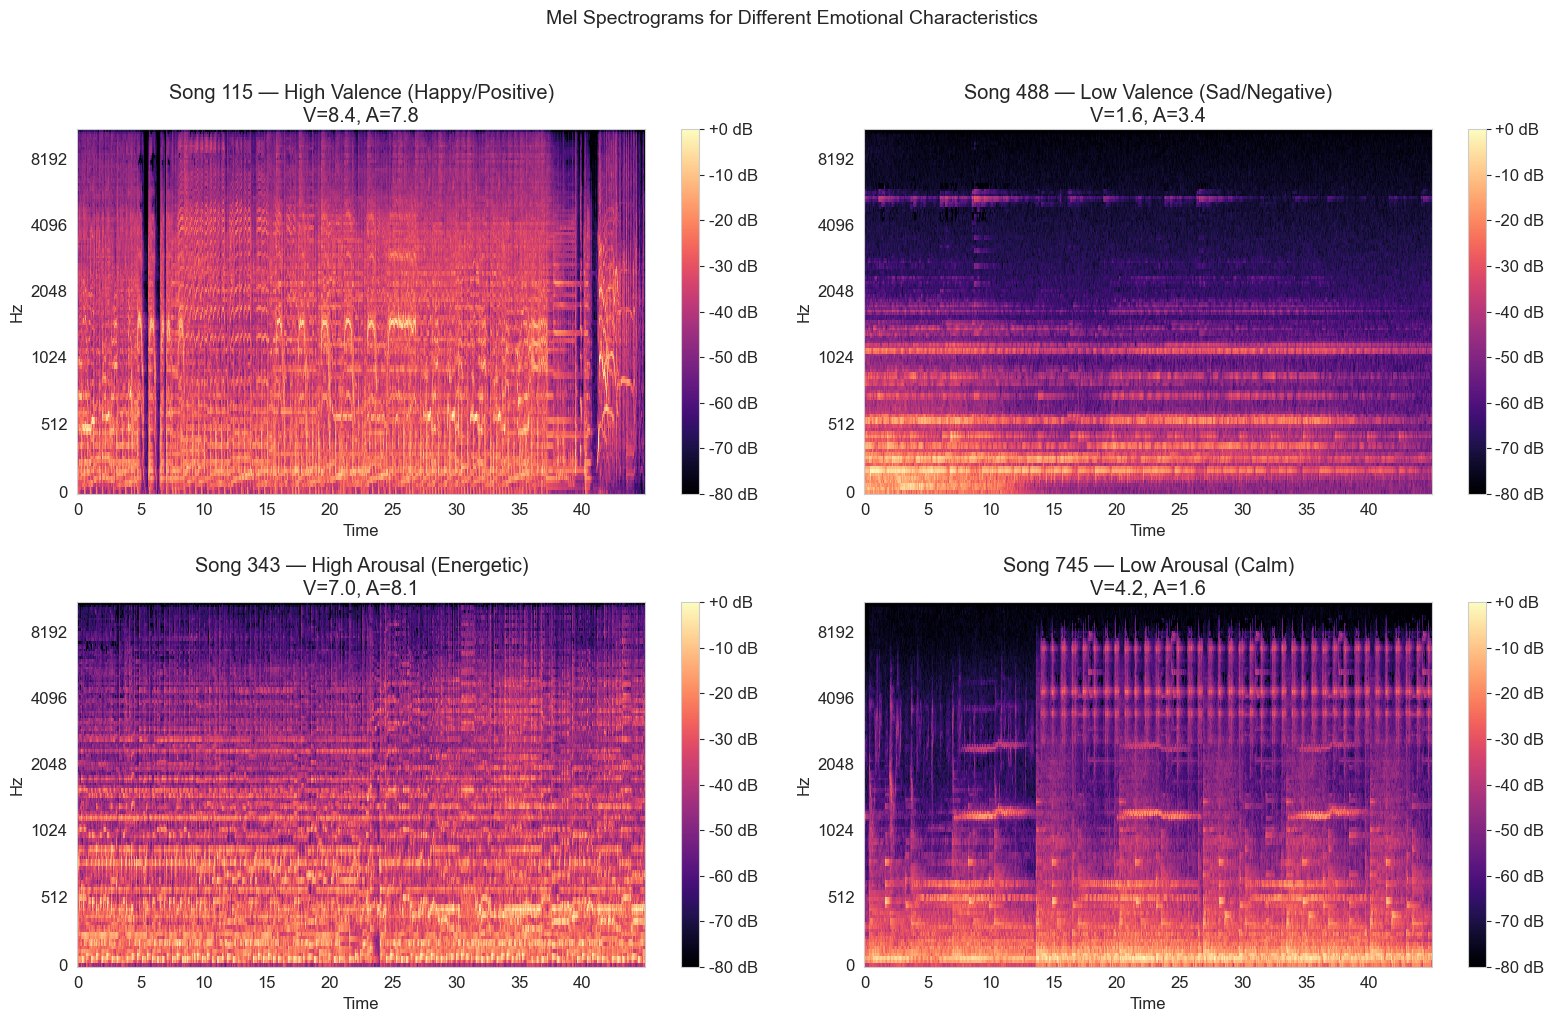

In [7]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# 1. Definisikan ulang konstanta yang dibutuhkan oleh visualisasi
SR = 22050
MEL_CONFIGS = [
    {"n_mels": 128, "hop_length": 512,  "label": "fine_freq"},
    {"n_mels": 64,  "hop_length": 256,  "label": "fine_time"},
    {"n_mels": 128, "hop_length": 1024, "label": "wide_context"},
]

# Pastikan variabel 'annotations' juga sudah di-load/didefinisikan sebelumnya di notebook ini
# valid_annot = annotations[annotations['song_id'].isin(mel_spectrograms.keys())].copy()

# 2. Find songs with extreme emotional characteristics
valid_annot = annotations[annotations['song_id'].isin(mel_spectrograms.keys())].copy()

# Sort by valence to find extremes
high_valence = valid_annot.nlargest(1, 'valence_mean').iloc[0]
low_valence = valid_annot.nsmallest(1, 'valence_mean').iloc[0]
high_arousal = valid_annot.nlargest(1, 'arousal_mean').iloc[0]
low_arousal = valid_annot.nsmallest(1, 'arousal_mean').iloc[0]

samples = [
    (high_valence, "High Valence (Happy/Positive)"),
    (low_valence, "Low Valence (Sad/Negative)"),
    (high_arousal, "High Arousal (Energetic)"),
    (low_arousal, "Low Arousal (Calm)"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Use the first mel config's hop_length for display
_display_hop = MEL_CONFIGS[0]["hop_length"]

for i, (song_row, title) in enumerate(samples):
    sid = int(song_row['song_id'])
    mel_spec = mel_spectrograms[sid]

    img = librosa.display.specshow(
        mel_spec, sr=SR, hop_length=_display_hop,
        x_axis='time', y_axis='mel', ax=axes[i]
    )
    axes[i].set_title(f"Song {sid} — {title}\n"
                      f"V={song_row['valence_mean']:.1f}, A={song_row['arousal_mean']:.1f}")
    fig.colorbar(img, ax=axes[i], format="%+2.0f dB")

plt.suptitle("Mel Spectrograms for Different Emotional Characteristics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Valence threshold: 5.0
Arousal threshold: 5.0

Dropped 0 ambiguous borderline samples (margin=0.0)

Emotion category distribution:
emotion
Sad/Depressed    686
Happy/Excited    647
Calm/Relaxed     240
Angry/Tense      229
Name: count, dtype: int64

Total samples: 1802


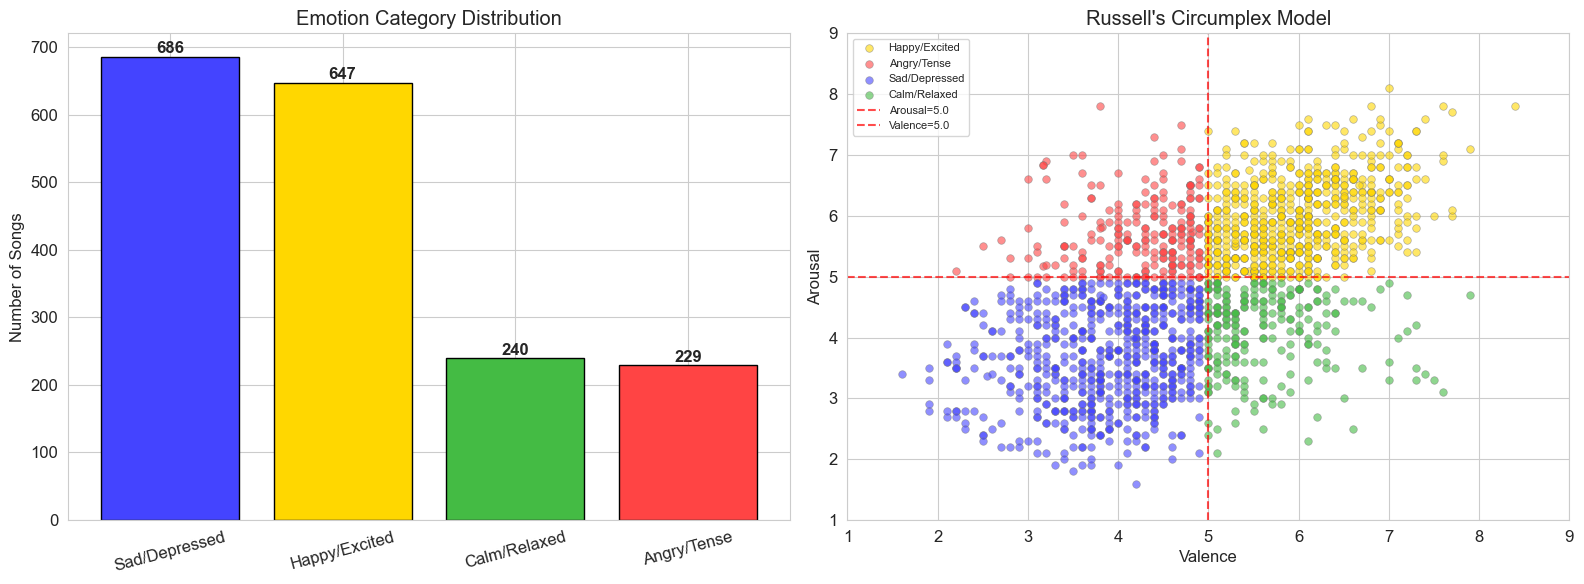

In [8]:
# ============================================================
# Quadrant thresholds + emotion mapping
# ============================================================
# Using fixed thresholds at the scale midpoint (5.0).
# KDE valley detection was previously used but found NO valleys
# in either distribution, falling back to median ≈ 4.9 anyway.
# Hardcoded 5.0 is simpler and essentially equivalent.

valid_annot = annotations[annotations['song_id'].isin(mel_spectrograms.keys())].copy()

VALENCE_THRESHOLD = 5.0
AROUSAL_THRESHOLD = 5.0

print(f"Valence threshold: {VALENCE_THRESHOLD}")
print(f"Arousal threshold: {AROUSAL_THRESHOLD}")


# ============================================================
# Emotion mapping using thresholds
# ============================================================
MARGIN = 0.0  # Retain ALL songs — no borderline filtering

def map_emotion(valence, arousal, val_threshold=VALENCE_THRESHOLD,
                aro_threshold=AROUSAL_THRESHOLD, margin=MARGIN):
    """
    Map valence and arousal values to emotion categories using Russell's
    Circumplex Model with fixed thresholds.
    """
    if abs(valence - val_threshold) < margin or abs(arousal - aro_threshold) < margin:
        return None

    if valence >= val_threshold and arousal >= aro_threshold:
        return "Happy/Excited"
    elif valence < val_threshold and arousal >= aro_threshold:
        return "Angry/Tense"
    elif valence < val_threshold and arousal < aro_threshold:
        return "Sad/Depressed"
    else:  # valence >= val_threshold and arousal < aro_threshold
        return "Calm/Relaxed"


# Apply emotion mapping
valid_annot['emotion'] = valid_annot.apply(
    lambda row: map_emotion(row['valence_mean'], row['arousal_mean']), axis=1
)

# Filter out ambiguous (borderline) samples
n_before = len(valid_annot)
valid_annot = valid_annot.dropna(subset=['emotion']).reset_index(drop=True)
n_dropped = n_before - len(valid_annot)
print(f"\nDropped {n_dropped} ambiguous borderline samples (margin={MARGIN})")

print("\nEmotion category distribution:")
print(valid_annot['emotion'].value_counts())
print(f"\nTotal samples: {len(valid_annot)}")

# Visualize emotion distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
emotion_counts = valid_annot['emotion'].value_counts()
colors = {'Happy/Excited': '#FFD700', 'Angry/Tense': '#FF4444',
          'Sad/Depressed': '#4444FF', 'Calm/Relaxed': '#44BB44'}
bars = axes[0].bar(emotion_counts.index, emotion_counts.values,
                   color=[colors[e] for e in emotion_counts.index], edgecolor='black')
axes[0].set_ylabel('Number of Songs')
axes[0].set_title('Emotion Category Distribution')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', fontweight='bold')

# Scatter plot colored by emotion
for emotion, color in colors.items():
    subset = valid_annot[valid_annot['emotion'] == emotion]
    axes[1].scatter(subset['valence_mean'], subset['arousal_mean'],
                    c=color, label=emotion, alpha=0.6, s=30, edgecolors='gray', linewidths=0.5)

axes[1].axhline(y=AROUSAL_THRESHOLD, color='red', linestyle='--', alpha=0.7, label=f'Arousal={AROUSAL_THRESHOLD:.1f}')
axes[1].axvline(x=VALENCE_THRESHOLD, color='red', linestyle='--', alpha=0.7, label=f'Valence={VALENCE_THRESHOLD:.1f}')
axes[1].set_xlabel('Valence')
axes[1].set_ylabel('Arousal')
axes[1].set_title("Russell's Circumplex Model")
axes[1].legend(loc='upper left', fontsize=8)
axes[1].set_xlim(1, 9)
axes[1].set_ylim(1, 9)

plt.tight_layout()
plt.show()


In [9]:
def extract_feature_vector(mel_spec_db):
    """
    Extract a fixed-length feature vector from a Mel spectrogram by computing
    summary statistics across the time axis for each Mel frequency band.

    Parameters:
        mel_spec_db: Log-scaled Mel spectrogram (n_mels x time_frames)

    Returns:
        Feature vector of shape (n_mels * 4,) containing mean, std, min, max per band
    """
    mel_mean = np.mean(mel_spec_db, axis=1)
    mel_std = np.std(mel_spec_db, axis=1)
    mel_min = np.min(mel_spec_db, axis=1)
    mel_max = np.max(mel_spec_db, axis=1)

    return np.concatenate([mel_mean, mel_std, mel_min, mel_max])


# Build feature matrix X and label array y
feature_list = []
label_list = []
song_ids_list = []
valence_list = []
arousal_list = []

for idx, row in valid_annot.iterrows():
    song_id = int(row['song_id'])
    if song_id in mel_spectrograms:
        mel_spec = mel_spectrograms[song_id]
        features = extract_feature_vector(mel_spec)
        feature_list.append(features)
        label_list.append(row['emotion'])
        song_ids_list.append(song_id)
        valence_list.append(row['valence_mean'])
        arousal_list.append(row['arousal_mean'])

X = np.array(feature_list)
y = np.array(label_list)
song_ids_arr = np.array(song_ids_list)
valence_arr = np.array(valence_list)
arousal_arr = np.array(arousal_list)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

n_mels_used = MEL_CONFIGS[0]["n_mels"]
print(f"Feature matrix shape: {X.shape}")
print(f"Label array shape: {y.shape}")
print(f"Feature vector size per track: {X.shape[1]} "
      f"({n_mels_used} Mel bands × 4 statistics)")
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"\nClass distribution:")
for cls, count in zip(*np.unique(y, return_counts=True)):
    print(f"  {cls}: {count} ({count/len(y)*100:.1f}%)")

Feature matrix shape: (1802, 512)
Label array shape: (1802,)
Feature vector size per track: 512 (128 Mel bands × 4 statistics)

Label encoding: {np.str_('Angry/Tense'): np.int64(0), np.str_('Calm/Relaxed'): np.int64(1), np.str_('Happy/Excited'): np.int64(2), np.str_('Sad/Depressed'): np.int64(3)}

Class distribution:
  Angry/Tense: 229 (12.7%)
  Calm/Relaxed: 240 (13.3%)
  Happy/Excited: 647 (35.9%)
  Sad/Depressed: 686 (38.1%)


In [10]:
# ============================================================
# Compact CNN Setup — reproducible training on spectrogram crops
# ============================================================
import math
import random
from collections import defaultdict

import tensorflow as tf
from tensorflow.keras import layers, callbacks, regularizers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU(s) detected: {len(gpus)}")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — training will use CPU")

print(f"TensorFlow version: {tf.__version__}")


No GPU detected — training will use CPU
TensorFlow version: 2.20.0


In [11]:
# ============================================================
# Prepare fixed multi-crop CNN data + auxiliary valence/arousal targets
# + handcrafted arousal features for dual-branch model
# WITH ENHANCED AUDIO AUGMENTATION for minority class balancing
# ============================================================
from sklearn.preprocessing import StandardScaler

CROP_DURATION_SEC = 12.0
TRAIN_CROPS_PER_SONG = 3
EVAL_CROPS_PER_SONG = 5
TARGET_FREQ = 96
TARGET_TIME = 160
MIN_DB = -80.0
INPUT_SHAPE = (TARGET_FREQ, TARGET_TIME, len(MEL_CONFIGS) + 1)  # +1 for chroma channel

# Use the data-driven thresholds from cell 6
AXIS_THRESHOLD_VALENCE = VALENCE_THRESHOLD
AXIS_THRESHOLD_AROUSAL = AROUSAL_THRESHOLD

# --- Augmentation parameters ---
MAX_TIME_MASK_WIDTH = 20    # max frames to mask in time
MAX_FREQ_MASK_WIDTH = 12    # max frequency bins to mask
NOISE_STD = 0.02            # std dev of Gaussian noise
MAX_SHIFT_FRAMES = 15       # max frames to shift in time
AUGMENT_PROB = 0.5           # probability of applying each augment type (standard)
AUGMENT_PROB_HARD = 0.75     # higher probability for hard classes

# Additional augmentation parameters for hard classes
PITCH_SHIFT_BINS = 4         # max frequency bins to roll for pseudo pitch shift
GAIN_RANGE = (0.8, 1.2)      # random gain multiplier range
CUTOUT_SIZE_FREQ = 8         # cutout patch height (freq bins)
CUTOUT_SIZE_TIME = 12        # cutout patch width (time frames)
MAX_CUTOUT_PATCHES = 2       # max random cutout patches

song_meta = valid_annot.set_index('song_id')[['valence_mean', 'arousal_mean']]


def temporal_crop(mel_spec_db, crop_frames, position_ratio):
    """Extract a time crop while preserving the original Mel resolution."""
    n_frames = mel_spec_db.shape[1]
    if n_frames <= crop_frames:
        pad_width = crop_frames - n_frames
        return np.pad(
            mel_spec_db,
            ((0, 0), (0, pad_width)),
            mode='constant',
            constant_values=mel_spec_db.min()
        )

    start = int(round(position_ratio * (n_frames - crop_frames)))
    end = start + crop_frames
    return mel_spec_db[:, start:end]


def resize_and_scale_mel(mel_spec_db, target_freq=TARGET_FREQ, target_time=TARGET_TIME, min_db=MIN_DB):
    """Resize a crop and map dB values into [0, 1] for stable CNN training."""
    mel_clipped = np.clip(mel_spec_db, min_db, 0.0).astype(np.float32)
    mel_scaled = (mel_clipped - min_db) / abs(min_db)
    mel_scaled = tf.image.resize(
        mel_scaled[..., np.newaxis],
        [target_freq, target_time],
        method='bilinear'
    ).numpy().squeeze(-1)
    return np.clip(mel_scaled, 0.0, 1.0).astype(np.float16)


def get_axis_targets(song_id):
    """Binary valence/arousal targets using data-driven thresholds."""
    row = song_meta.loc[int(song_id)]
    valence_high = 1.0 if row['valence_mean'] >= AXIS_THRESHOLD_VALENCE else 0.0
    arousal_high = 1.0 if row['arousal_mean'] >= AXIS_THRESHOLD_AROUSAL else 0.0
    return valence_high, arousal_high


# ============================================================
# Augmentation functions for spectrogram crops
# ============================================================

def augment_time_mask(crop, rng):
    """Apply SpecAugment-style time masking to a multi-channel crop."""
    crop = crop.copy()
    _, time_steps, n_channels = crop.shape
    mask_width = rng.integers(1, MAX_TIME_MASK_WIDTH + 1)
    mask_start = rng.integers(0, max(1, time_steps - mask_width))
    crop[:, mask_start:mask_start + mask_width, :] = 0.0
    return crop


def augment_freq_mask(crop, rng):
    """Apply SpecAugment-style frequency masking to a multi-channel crop."""
    crop = crop.copy()
    freq_bins, _, n_channels = crop.shape
    mask_width = rng.integers(1, MAX_FREQ_MASK_WIDTH + 1)
    mask_start = rng.integers(0, max(1, freq_bins - mask_width))
    crop[mask_start:mask_start + mask_width, :, :] = 0.0
    return crop


def augment_gaussian_noise(crop, rng):
    """Add small Gaussian noise to the spectrogram values."""
    crop = crop.copy().astype(np.float32)
    noise = rng.normal(0.0, NOISE_STD, size=crop.shape).astype(np.float32)
    crop = np.clip(crop + noise, 0.0, 1.0)
    return crop.astype(np.float16)


def augment_time_shift(crop, rng):
    """Randomly shift the spectrogram along the time axis with wrapping."""
    crop = crop.copy()
    _, time_steps, _ = crop.shape
    shift = rng.integers(-MAX_SHIFT_FRAMES, MAX_SHIFT_FRAMES + 1)
    if shift != 0:
        crop = np.roll(crop, shift, axis=1)
    return crop


# --- Additional augmentation techniques for hard classes ---

def augment_pitch_shift(crop, rng):
    """Pseudo pitch shift by rolling along the frequency axis."""
    crop = crop.copy()
    shift = rng.integers(-PITCH_SHIFT_BINS, PITCH_SHIFT_BINS + 1)
    if shift != 0:
        crop = np.roll(crop, shift, axis=0)
        if shift > 0:
            crop[:shift, :, :] = 0.0
        else:
            crop[shift:, :, :] = 0.0
    return crop


def augment_random_gain(crop, rng):
    """Apply a random gain factor to simulate volume variation."""
    crop = crop.copy().astype(np.float32)
    gain = rng.uniform(GAIN_RANGE[0], GAIN_RANGE[1])
    crop = np.clip(crop * gain, 0.0, 1.0)
    return crop.astype(np.float16)


def augment_cutout(crop, rng):
    """Apply random rectangular cutout patches (Cutout augmentation)."""
    crop = crop.copy()
    freq_bins, time_steps, _ = crop.shape
    n_patches = rng.integers(1, MAX_CUTOUT_PATCHES + 1)
    for _ in range(n_patches):
        f_start = rng.integers(0, max(1, freq_bins - CUTOUT_SIZE_FREQ))
        t_start = rng.integers(0, max(1, time_steps - CUTOUT_SIZE_TIME))
        crop[f_start:f_start + CUTOUT_SIZE_FREQ, t_start:t_start + CUTOUT_SIZE_TIME, :] = 0.0
    return crop


def augment_freq_warp(crop, rng):
    """Simple frequency warping: squeeze or stretch a frequency band."""
    crop = crop.copy().astype(np.float32)
    freq_bins, time_steps, n_ch = crop.shape
    band_center = rng.integers(freq_bins // 4, 3 * freq_bins // 4)
    band_half = rng.integers(4, min(12, freq_bins // 4))
    low = max(0, band_center - band_half)
    high = min(freq_bins, band_center + band_half)
    band = crop[low:high, :, :]
    warp_factor = rng.uniform(0.8, 1.2)
    new_height = max(2, int(round((high - low) * warp_factor)))
    band_resized = tf.image.resize(
        band, [new_height, time_steps], method='bilinear'
    ).numpy()
    actual = min(new_height, high - low)
    crop[low:low + actual, :, :] = np.clip(band_resized[:actual], 0.0, 1.0)
    return crop.astype(np.float16)


def augment_spectrogram_crop(crop, seed=None, hard_class=False):
    """
    Apply a random combination of augmentation techniques to a single
    spectrogram crop of shape (TARGET_FREQ, TARGET_TIME, num_channels).

    If hard_class=True, uses higher augmentation probability and applies
    additional augmentation techniques for more diverse training samples.
    """
    rng = np.random.default_rng(seed)
    prob = AUGMENT_PROB_HARD if hard_class else AUGMENT_PROB

    if rng.random() < prob:
        crop = augment_time_mask(crop, rng)
    if rng.random() < prob:
        crop = augment_freq_mask(crop, rng)
    if rng.random() < prob:
        crop = augment_gaussian_noise(crop, rng)
    if rng.random() < prob:
        crop = augment_time_shift(crop, rng)

    if hard_class:
        if rng.random() < 0.6:
            crop = augment_pitch_shift(crop, rng)
        if rng.random() < 0.5:
            crop = augment_random_gain(crop, rng)
        if rng.random() < 0.4:
            crop = augment_cutout(crop, rng)
        if rng.random() < 0.3:
            crop = augment_freq_warp(crop, rng)

    return crop


def compute_augmentation_multiplier(class_counts, target_class_idx, hard_classes=None):
    """
    Compute how many EXTRA augmented crop-sets to generate for a minority class
    to approximately match the largest class count.
    """
    max_count = max(class_counts.values())
    current_count = class_counts[target_class_idx]
    if current_count >= max_count:
        multiplier = 0
    else:
        multiplier = max(0, round(max_count / current_count) - 1)
    if hard_classes and target_class_idx in hard_classes and multiplier == 0:
        multiplier = 1
    return multiplier


def build_segment_dataset(song_ids, song_labels, num_crops, augment_minority=False):
    """
    Create deterministic crops per song for stable training.
    Returns spectrogram crops AND per-crop arousal feature vectors.
    """
    crop_ratios = [0.5] if num_crops == 1 else np.linspace(0.0, 1.0, num_crops)
    X_segments = []
    X_arousal_feats = []
    y_emotion = []
    y_valence = []
    y_arousal = []
    crop_song_ids = []

    hard_class_names = {'Angry/Tense', 'Calm/Relaxed'}
    hard_class_indices = set()
    for idx, name in enumerate(CLASS_NAMES):
        if name in hard_class_names:
            hard_class_indices.add(idx)

    aug_multipliers = {}
    if augment_minority:
        class_counts = defaultdict(int)
        for label in song_labels:
            class_counts[int(label)] += 1
        for cls_idx in class_counts:
            aug_multipliers[cls_idx] = compute_augmentation_multiplier(
                class_counts, cls_idx, hard_classes=hard_class_indices
            )
        print(f"  Hard classes (enhanced augmentation): {[CLASS_NAMES[i] for i in hard_class_indices]}")
        print(f"  Augmentation multipliers per class: {dict(aug_multipliers)}")
        print(f"  Class counts: {dict(class_counts)}")

    aug_seed_counter = SEED * 1000

    for song_id, label in zip(song_ids, song_labels):
        valence_target, arousal_target = get_axis_targets(song_id)
        mel_bundle = mel_spectrograms_multi[int(song_id)]
        label_int = int(label)
        is_hard = label_int in hard_class_indices
        arousal_feat = mel_bundle['arousal_features']  # shape: (25,)

        for ratio in crop_ratios:
            channels = []
            for cfg in MEL_CONFIGS:
                mel = mel_bundle[cfg["label"]]
                crop_frames = max(16, int(round(CROP_DURATION_SEC * SR / cfg["hop_length"])))
                mel_crop = temporal_crop(mel, crop_frames=crop_frames, position_ratio=ratio)
                channels.append(resize_and_scale_mel(mel_crop))

            chroma = mel_bundle["chroma"]
            chroma_crop_frames = max(16, int(round(CROP_DURATION_SEC * SR / MEL_CONFIGS[0]["hop_length"])))
            chroma_crop = temporal_crop(chroma, crop_frames=chroma_crop_frames, position_ratio=ratio)
            channels.append(resize_and_scale_mel(chroma_crop))

            original_crop = np.stack(channels, axis=-1)
            X_segments.append(original_crop)
            X_arousal_feats.append(arousal_feat)
            y_emotion.append(label_int)
            y_valence.append(np.float32(valence_target))
            y_arousal.append(np.float32(arousal_target))
            crop_song_ids.append(int(song_id))

            # Generate augmented copies for minority / hard classes
            if augment_minority and label_int in aug_multipliers:
                n_aug = aug_multipliers[label_int]
                for aug_i in range(n_aug):
                    aug_seed_counter += 1
                    aug_crop = augment_spectrogram_crop(
                        original_crop, seed=aug_seed_counter, hard_class=is_hard
                    )
                    X_segments.append(aug_crop)
                    X_arousal_feats.append(arousal_feat)  # same features, different spectrogram crop
                    y_emotion.append(label_int)
                    y_valence.append(np.float32(valence_target))
                    y_arousal.append(np.float32(arousal_target))
                    crop_song_ids.append(int(song_id))

    return (
        np.asarray(X_segments, dtype=np.float16),
        np.asarray(X_arousal_feats, dtype=np.float32),
        np.asarray(y_emotion, dtype=np.int32),
        np.asarray(y_valence, dtype=np.float32),
        np.asarray(y_arousal, dtype=np.float32),
        np.asarray(crop_song_ids, dtype=np.int32),
    )


song_ids_all = valid_annot['song_id'].to_numpy()
song_labels_all = valid_annot['emotion'].to_numpy()

le_cnn = LabelEncoder()
y_song_encoded = le_cnn.fit_transform(song_labels_all)
NUM_CLASSES = len(le_cnn.classes_)
CLASS_NAMES = list(le_cnn.classes_)

song_ids_tv, song_ids_test, y_tv_songs, y_test_songs = train_test_split(
    song_ids_all,
    y_song_encoded,
    test_size=0.15,
    random_state=SEED,
    stratify=y_song_encoded,
)

song_ids_train, song_ids_val, y_train_songs, y_val_songs = train_test_split(
    song_ids_tv,
    y_tv_songs,
    test_size=0.176,
    random_state=SEED,
    stratify=y_tv_songs,
)

# Build training data WITH augmentation for minority classes
print("Building training data (augmentation disabled to avoid over-correction)...")
X_train_crops, X_train_arousal, y_train_emotion, y_train_valence, y_train_arousal, train_crop_song_ids = build_segment_dataset(
    song_ids_train, y_train_songs, TRAIN_CROPS_PER_SONG, augment_minority=False
)

# Build val/test data WITHOUT augmentation
X_val_crops, X_val_arousal, y_val_emotion, y_val_valence, y_val_arousal, val_crop_song_ids = build_segment_dataset(
    song_ids_val, y_val_songs, EVAL_CROPS_PER_SONG, augment_minority=False
)
X_test_crops, X_test_arousal, y_test_emotion, y_test_valence, y_test_arousal, test_crop_song_ids = build_segment_dataset(
    song_ids_test, y_test_songs, EVAL_CROPS_PER_SONG, augment_minority=False
)

# Fit scaler on training arousal features, transform all splits
arousal_scaler = StandardScaler()
X_train_arousal = arousal_scaler.fit_transform(X_train_arousal)
X_val_arousal = arousal_scaler.transform(X_val_arousal)
X_test_arousal = arousal_scaler.transform(X_test_arousal)

print(
    f"Song split sizes -- Train: {len(song_ids_train)}, "
    f"Val: {len(song_ids_val)}, Test: {len(song_ids_test)}"
)
print(
    f"Spec crop shapes -- Train: {X_train_crops.shape}, "
    f"Val: {X_val_crops.shape}, Test: {X_test_crops.shape}"
)
print(
    f"Arousal feat shapes -- Train: {X_train_arousal.shape}, "
    f"Val: {X_val_arousal.shape}, Test: {X_test_arousal.shape}"
)
print(f"Classes: {CLASS_NAMES}")

print(f"\nThresholds used — Valence: {AXIS_THRESHOLD_VALENCE:.3f}, Arousal: {AXIS_THRESHOLD_AROUSAL:.3f}")

print("\nSong distribution per split:")
for idx, cls in enumerate(CLASS_NAMES):
    train_count = int((y_train_songs == idx).sum())
    val_count = int((y_val_songs == idx).sum())
    test_count = int((y_test_songs == idx).sum())
    print(f"  {cls}: train={train_count}, val={val_count}, test={test_count}")

print("\nCrop distribution in training data (with augmentation):")
for idx, cls in enumerate(CLASS_NAMES):
    crop_count = int((y_train_emotion == idx).sum())
    print(f"  {cls}: {crop_count} crops")


Building training data (augmentation disabled to avoid over-correction)...
Song split sizes -- Train: 1261, Val: 270, Test: 271
Spec crop shapes -- Train: (3783, 96, 160, 4), Val: (1350, 96, 160, 4), Test: (1355, 96, 160, 4)
Arousal feat shapes -- Train: (3783, 25), Val: (1350, 25), Test: (1355, 25)
Classes: ['Angry/Tense', 'Calm/Relaxed', 'Happy/Excited', 'Sad/Depressed']

Thresholds used — Valence: 5.000, Arousal: 5.000

Song distribution per split:
  Angry/Tense: train=160, val=34, test=35
  Calm/Relaxed: train=168, val=36, test=36
  Happy/Excited: train=453, val=97, test=97
  Sad/Depressed: train=480, val=103, test=103

Crop distribution in training data (with augmentation):
  Angry/Tense: 480 crops
  Calm/Relaxed: 504 crops
  Happy/Excited: 1359 crops
  Sad/Depressed: 1440 crops


In [13]:
# ============================================================
# Dual-Branch Multi-task CNN:
#   Branch 1: Spectrogram CNN (existing architecture)
#   Branch 2: Dense network for handcrafted arousal features
#   Merged → emotion/valence/arousal heads
# WITH FOCAL LOSS + CLASS WEIGHTS
# WITHOUT apply_calm_relaxed_override (let the model decide)
# ============================================================
BEST_MODEL_PATH = 'best_cnn_compact.keras'
BATCH_SIZE = 32
EPOCHS = 60
AXIS_BLEND = 0.30
NUM_AROUSAL_FEATURES = 25  # Berdasarkan kode aslimu
NUM_CLASSES = len(CLASS_NAMES) if 'CLASS_NAMES' in locals() else 4 # Sesuaikan jumlah class
# --- Class weights ---
HARD_CLASS_NAMES = {'Angry/Tense', 'Calm/Relaxed'}
CLASS_WEIGHT_BOOST = 2.0

class_weights_dict = {}
for idx, name in enumerate(CLASS_NAMES):
    if name in HARD_CLASS_NAMES:
        class_weights_dict[idx] = CLASS_WEIGHT_BOOST
    else:
        class_weights_dict[idx] = 1.0

print(f"Class weights: { {CLASS_NAMES[k]: v for k, v in class_weights_dict.items()} }")

class_weights_tensor = tf.constant(
    [class_weights_dict[i] for i in range(NUM_CLASSES)], dtype=tf.float32
)


# ============================================================
# Focal Loss implementation
# ============================================================
class SparseCategoricalFocalLoss(tf.keras.losses.Loss):
    """
    Focal loss for multi-class classification with sparse (integer) labels.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, class_weights=None, name='sparse_focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.class_weights = class_weights

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        indices = tf.stack([tf.range(tf.shape(y_true)[0]), y_true], axis=1)
        p_t = tf.gather_nd(y_pred, indices)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)
        ce_loss = -tf.math.log(p_t)
        if self.class_weights is not None:
            alpha_t = tf.gather(self.class_weights, y_true)
            loss = alpha_t * focal_weight * ce_loss
        else:
            loss = focal_weight * ce_loss
        return tf.reduce_mean(loss)

    def get_config(self):
        config = super().get_config()
        config.update({
            'gamma': self.gamma,
            'class_weights': self.class_weights.numpy().tolist() if self.class_weights is not None else None,
        })
        return config


focal_loss = SparseCategoricalFocalLoss(
    gamma=2.0,
    class_weights=None,  # Removed: class weights disabled to avoid over-correction with focal loss
)
print(f"Focal loss gamma: {focal_loss.gamma}")


def make_balanced_train_dataset(X_spec, X_arousal, y_emotion, y_valence, y_arousal, batch_size):
    """
    Oversampling-based balanced sampler for dual-input model.
    """
    classes = sorted(set(y_emotion))
    class_indices = {c: np.where(y_emotion == c)[0] for c in classes}
    crop_counts = {CLASS_NAMES[c]: len(idx) for c, idx in class_indices.items()}
    target_per_class = max(len(idx) for idx in class_indices.values())

    rng = np.random.default_rng(SEED)
    balanced_indices = []
    for c in classes:
        idx = class_indices[c]
        if len(idx) < target_per_class:
            extra = rng.choice(idx, target_per_class - len(idx), replace=True)
            idx = np.concatenate([idx, extra])
        balanced_indices.append(idx)

    balanced_indices = np.concatenate(balanced_indices)
    rng.shuffle(balanced_indices)

    X_spec_bal = X_spec[balanced_indices]
    X_aro_bal = X_arousal[balanced_indices]
    y_emo_bal = y_emotion[balanced_indices]
    y_val_bal = y_valence[balanced_indices]
    y_aro_bal = y_arousal[balanced_indices]

    ds = tf.data.Dataset.from_tensor_slices((
        {'spec_input': tf.cast(X_spec_bal, tf.float32),
         'arousal_input': tf.cast(X_aro_bal, tf.float32)},
        {'emotion': y_emo_bal, 'valence': y_val_bal, 'arousal': y_aro_bal},
    )).shuffle(len(balanced_indices), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds, crop_counts, target_per_class


def make_eval_dataset(X_spec, X_arousal, y_emotion, y_valence, y_arousal, batch_size):
    ds = tf.data.Dataset.from_tensor_slices((
        {'spec_input': tf.cast(X_spec, tf.float32),
         'arousal_input': tf.cast(X_arousal, tf.float32)},
        {'emotion': y_emotion, 'valence': y_valence, 'arousal': y_arousal},
    )).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def conv_bn_act(x, filters, kernel_size=3, strides=1, weight_decay=1e-4):
    x = layers.SeparableConv2D(
        filters,
        kernel_size,
        strides=strides,
        padding='same',
        use_bias=False,
        depthwise_regularizer=regularizers.l2(weight_decay),
        pointwise_regularizer=regularizers.l2(weight_decay),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    return x


def residual_block(x, filters, pool=False, dropout_rate=0.0):
    shortcut = x
    x = conv_bn_act(x, filters)
    x = conv_bn_act(x, filters)

    if pool:
        x = layers.AveragePooling2D(pool_size=2)(x)
        shortcut = layers.AveragePooling2D(pool_size=2)(shortcut)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('swish')(x)

    if dropout_rate > 0:
        x = layers.SpatialDropout2D(dropout_rate)(x)
    return x


def build_multitask_dual_branch_cnn(spec_shape, arousal_feat_dim, num_classes):
    """
    Dual-branch architecture:
      - Spectrogram branch: ResNet-style CNN
      - Arousal features branch: Dense layers
      - Merged via concatenation
      - Multi-task heads: emotion, valence, arousal
    """
    # === Branch 1: Spectrogram CNN ===
    spec_input = layers.Input(shape=spec_shape, name='spec_input')

    x = layers.Conv2D(24, 5, strides=2, padding='same', use_bias=False)(spec_input)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)

    x = residual_block(x, 24, pool=False, dropout_rate=0.05)
    x = residual_block(x, 48, pool=True, dropout_rate=0.08)
    x = residual_block(x, 96, pool=True, dropout_rate=0.10)
    x = residual_block(x, 144, pool=True, dropout_rate=0.12)
    x = residual_block(x, 192, pool=True, dropout_rate=0.15)

    gap = layers.GlobalAveragePooling2D()(x)
    gmp = layers.GlobalMaxPooling2D()(x)
    spec_features = layers.Concatenate()([gap, gmp])  # (batch, 384)

    # === Branch 2: Dense arousal features ===
    arousal_input = layers.Input(shape=(arousal_feat_dim,), name='arousal_input')

    a = layers.Dense(64, use_bias=False, kernel_regularizer=regularizers.l2(1e-4))(arousal_input)
    a = layers.BatchNormalization()(a)
    a = layers.Activation('swish')(a)
    a = layers.Dropout(0.3)(a)

    a = layers.Dense(32, use_bias=False, kernel_regularizer=regularizers.l2(1e-4))(a)
    a = layers.BatchNormalization()(a)
    a = layers.Activation('swish')(a)
    a = layers.Dropout(0.2)(a)

    # === Merge branches ===
    merged = layers.Concatenate()([spec_features, a])  # (batch, 384 + 32 = 416)

    x = layers.Dense(160, use_bias=False, kernel_regularizer=regularizers.l2(8e-5))(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.25)(x)

    # === Multi-task heads ===
    emotion_output = layers.Dense(num_classes, activation='softmax', name='emotion')(x)
    valence_output = layers.Dense(1, activation='sigmoid', name='valence')(x)
    arousal_output = layers.Dense(1, activation='sigmoid', name='arousal')(x)

    return tf.keras.Model(
        inputs=[spec_input, arousal_input],
        outputs=[emotion_output, valence_output, arousal_output],
        name='dual_branch_multitask_cnn',
    )


def unpack_outputs(outputs):
    if isinstance(outputs, dict):
        emotion_probs = outputs['emotion']
        valence_probs = outputs['valence']
        arousal_probs = outputs['arousal']
    else:
        emotion_probs, valence_probs, arousal_probs = outputs

    return (
        np.asarray(emotion_probs, dtype=np.float32),
        np.asarray(valence_probs, dtype=np.float32).reshape(-1),
        np.asarray(arousal_probs, dtype=np.float32).reshape(-1),
    )


def blend_quadrant_probs(emotion_probs, valence_probs, arousal_probs, axis_blend=AXIS_BLEND):
    axis_probs = np.stack(
        [
            (1.0 - valence_probs) * arousal_probs,          # Angry/Tense
            valence_probs * (1.0 - arousal_probs),          # Calm/Relaxed
            valence_probs * arousal_probs,                  # Happy/Excited
            (1.0 - valence_probs) * (1.0 - arousal_probs),  # Sad/Depressed
        ],
        axis=1,
    )
    combined = (1.0 - axis_blend) * emotion_probs + axis_blend * axis_probs
    combined /= np.clip(combined.sum(axis=1, keepdims=True), 1e-8, None)
    return combined


class SongLevelMetrics(callbacks.Callback):
    """Aggregate crop predictions back to song level using class + axis heads."""

    def __init__(self, x_spec_val, x_arousal_val, y_val_emotion, song_ids, batch_size):
        super().__init__()
        self.x_spec_val = x_spec_val
        self.x_arousal_val = x_arousal_val
        self.y_val_emotion = y_val_emotion
        self.song_ids = song_ids
        self.batch_size = batch_size

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        outputs = self.model.predict(
            {'spec_input': self.x_spec_val, 'arousal_input': self.x_arousal_val},
            batch_size=self.batch_size, verbose=0
        )
        emotion_probs, valence_probs, arousal_probs = unpack_outputs(outputs)
        crop_probs = blend_quadrant_probs(emotion_probs, valence_probs, arousal_probs)

        grouped_probs = defaultdict(list)
        grouped_labels = {}
        for song_id, probs, label in zip(self.song_ids, crop_probs, self.y_val_emotion):
            grouped_probs[int(song_id)].append(probs)
            grouped_labels[int(song_id)] = int(label)

        y_true_song = []
        y_pred_song = []
        for song_id in grouped_probs:
            mean_prob = np.mean(grouped_probs[song_id], axis=0)
            y_true_song.append(grouped_labels[song_id])
            y_pred_song.append(int(np.argmax(mean_prob)))

        song_acc = accuracy_score(y_true_song, y_pred_song)
        weighted_f1 = f1_score(y_true_song, y_pred_song, average='weighted', zero_division=0)
        macro_f1 = f1_score(y_true_song, y_pred_song, average='macro', zero_division=0)
        logs['val_song_accuracy'] = song_acc
        logs['val_weighted_f1'] = weighted_f1
        logs['val_macro_f1'] = macro_f1
        print(
            f" - val_song_accuracy: {song_acc:.4f}"
            f" - val_weighted_f1: {weighted_f1:.4f}"
            f" - val_macro_f1: {macro_f1:.4f}",
            end='',
        )


# Using standard (non-oversampled) dataset — focal loss alone handles class imbalance
train_ds = make_eval_dataset(
    X_train_crops, X_train_arousal, y_train_emotion, y_train_valence, y_train_arousal, BATCH_SIZE
)
# Compute crop counts for reporting only
train_crop_counts = {}
for idx, name in enumerate(CLASS_NAMES):
    train_crop_counts[name] = int((y_train_emotion == idx).sum())
target_crops_per_class = max(train_crop_counts.values())
val_ds = make_eval_dataset(X_val_crops, X_val_arousal, y_val_emotion, y_val_valence, y_val_arousal, BATCH_SIZE)
test_ds = make_eval_dataset(X_test_crops, X_test_arousal, y_test_emotion, y_test_valence, y_test_arousal, BATCH_SIZE)

balanced_epoch_crops = target_crops_per_class * NUM_CLASSES
steps_per_epoch = max(1, math.ceil(balanced_epoch_crops / BATCH_SIZE))
song_metrics_cb = SongLevelMetrics(
    X_val_crops,
    X_val_arousal,
    y_val_emotion,
    val_crop_song_ids,
    batch_size=BATCH_SIZE,
)

tf.keras.backend.clear_session()
model = build_multitask_dual_branch_cnn(INPUT_SHAPE, NUM_AROUSAL_FEATURES, NUM_CLASSES)

WARMUP_EPOCHS = 3
BASE_LR = 2.5e-4

def warmup_schedule(epoch, lr):
    if epoch < WARMUP_EPOCHS:
        return BASE_LR * (epoch + 1) / WARMUP_EPOCHS
    return lr

warmup_cb = callbacks.LearningRateScheduler(warmup_schedule)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=BASE_LR, weight_decay=1e-4),
    loss={
        'emotion': focal_loss,
        'valence': 'binary_crossentropy',
        'arousal': 'binary_crossentropy',
    },
    loss_weights={
        'emotion': 1.0,
        'valence': 0.30,
        'arousal': 0.30,
    },
    metrics={
        'emotion': ['accuracy'],
        'valence': ['accuracy'],
        'arousal': ['accuracy'],
    },
)

print("Original crop counts in the training split:")
for cls, count in train_crop_counts.items():
    print(f"  {cls}: {count} crops")

print(f"\nBalanced sampler target per class per epoch: {target_crops_per_class} crops")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"\nLoss function: Sparse Categorical Focal Loss (gamma={focal_loss.gamma})")
print(f"Class weights: None (focal loss is the sole imbalance remedy)")
print(f"\nDual-branch architecture: Spectrogram CNN + {NUM_AROUSAL_FEATURES} arousal features")
model.summary()


Class weights: {'Angry/Tense': 2.0, 'Calm/Relaxed': 2.0, 'Happy/Excited': 1.0, 'Sad/Depressed': 1.0}
Focal loss gamma: 2.0
Original crop counts in the training split:
  Angry/Tense: 480 crops
  Calm/Relaxed: 504 crops
  Happy/Excited: 1359 crops
  Sad/Depressed: 1440 crops

Balanced sampler target per class per epoch: 1440 crops
Steps per epoch: 180

Loss function: Sparse Categorical Focal Loss (gamma=2.0)
Class weights: None (focal loss is the sole imbalance remedy)

Dual-branch architecture: Spectrogram CNN + 25 arousal features


Model: "dual_branch_multitask_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ spec_input          │ (None, 96, 160,   │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 48, 80,    │      2,400 │ spec_input[0][0]  │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 80,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 48, 80,    │        792 │ activation[0][0]  │
│ (SeparableConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 80,    │         96 │ separable_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 48, 80,    │        792 │ activation_1[0][… │
│ (SeparableConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 80,    │         96 │ separable_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 48, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 80,    │          0 │ activation_2[0][… │
│                     │ 24)               │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 48, 80,    │          0 │ add[0][0]         │
│ (Activation)        │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d   │ (None, 48, 80,    │          0 │ activation_3[0][… │
│ (SpatialDropout2D)  │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 48, 80,    │      1,368 │ spatial_dropout2… │
│ (SeparableConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 80,    │        192 │ separable_conv2d… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 48, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 48, 80,    │      2,736 │ activation_4[0][

 Total params: 252,942 (988.05 KB)

 Trainable params: 249,406 (974.24 KB)

 Non-trainable params: 3,536 (13.81 KB)

In [14]:
# sample_images, sample_targets = next(iter(train_ds.take(1)))
# print(f"Sample batch shape: {sample_images.shape}")
# print(f"Emotion labels: {sample_targets['emotion'][:10].numpy()}")
# print(f"Valence targets: {sample_targets['valence'][:10].numpy().reshape(-1)}")
# print(f"Arousal targets: {sample_targets['arousal'][:10].numpy().reshape(-1)}")


In [15]:
# ============================================================
# Train multi-task compact CNN
# ============================================================
early_stop = callbacks.EarlyStopping(
    monitor='val_macro_f1',
    mode='max',
    patience=10,
    restore_best_weights=True,
    verbose=1,
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_macro_f1',
    mode='max',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1,
)
ckpt = callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_macro_f1',
    mode='max',
    save_best_only=True,
    verbose=1,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    callbacks=[song_metrics_cb, warmup_cb, reduce_lr, early_stop, ckpt],
    verbose=1,
)

# model = tf.keras.models.load_model(BEST_MODEL_PATH)

print(f"\nBest crop-level val_emotion_accuracy: {max(history.history['val_emotion_accuracy']):.4f}")
print(f"Best song-level val_accuracy: {max(history.history['val_song_accuracy']):.4f}")
print(f"Best song-level val_weighted_f1: {max(history.history['val_weighted_f1']):.4f}")
print(f"Best song-level val_macro_f1: {max(history.history['val_macro_f1']):.4f}")
print(f"Total epochs run: {len(history.history['loss'])}")


Epoch 1/60
119/180 ━━━━━━━━━━━━━━━━━━━━ 43s 709ms/step - arousal_accuracy: 0.5537 - arousal_loss: 0.7288 - emotion_accuracy: 0.2988 - emotion_loss: 1.0639 - loss: 1.6156 - valence_accuracy: 0.5613 - valence_loss: 0.7155 - val_song_accuracy: 0.3815 - val_weighted_f1: 0.2351 - val_macro_f1: 0.1619
Epoch 1: val_macro_f1 improved from None to 0.16187, saving model to best_cnn_compact.keras

Epoch 1: finished saving model to best_cnn_compact.keras
180/180 ━━━━━━━━━━━━━━━━━━━━ 143s 588ms/step - arousal_accuracy: 0.5868 - arousal_loss: 0.6954 - emotion_accuracy: 0.3571 - emotion_loss: 0.9515 - loss: 1.4826 - valence_accuracy: 0.6019 - valence_loss: 0.6757 - val_arousal_accuracy: 0.4852 - val_arousal_loss: 0.7102 - val_emotion_accuracy: 0.4956 - val_emotion_loss: 0.6742 - val_loss: 1.2197 - val_valence_accuracy: 0.4926 - val_valence_loss: 0.6915 - val_song_accuracy: 0.3815 - val_weighted_f1: 0.2351 - val_macro_f1: 0.1619 - learning_rate: 8.3333e-05
Epoch 2/60
119/180 ━━━━━━━━━━━━━━━━━━━━ 44s 7

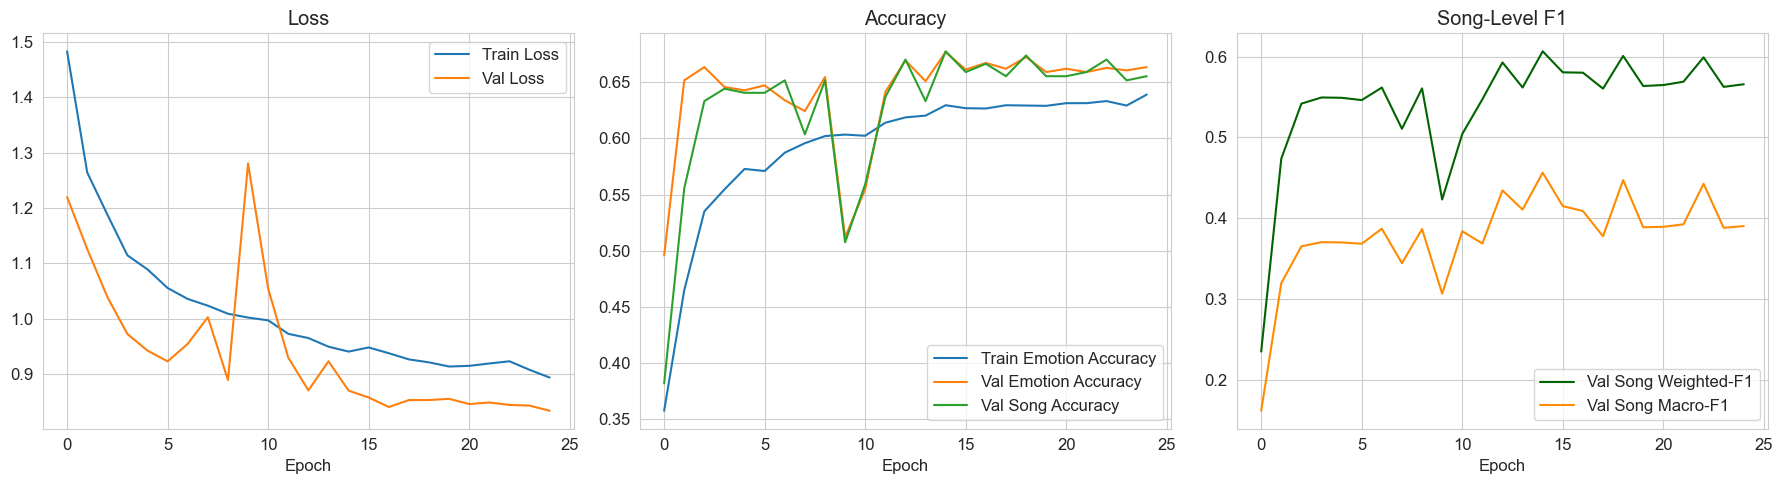

In [16]:
# ============================================================
# Training history
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(history.history['emotion_accuracy'], label='Train Emotion Accuracy')
axes[1].plot(history.history['val_emotion_accuracy'], label='Val Emotion Accuracy')
axes[1].plot(history.history['val_song_accuracy'], label='Val Song Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].grid(True)
axes[1].legend()

axes[2].plot(history.history['val_weighted_f1'], label='Val Song Weighted-F1', color='darkgreen')
axes[2].plot(history.history['val_macro_f1'], label='Val Song Macro-F1', color='darkorange')
axes[2].set_title('Song-Level F1')
axes[2].set_xlabel('Epoch')
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()


Crop-level Test Loss: 0.9096
Crop-level Emotion Accuracy: 0.6229
Crop-level Valence Accuracy: 0.7328
Crop-level Arousal Accuracy: 0.8170
Song-level Test Accuracy (blended + TTA): 0.6347
Song-level Test Weighted-F1: 0.5725
Song-level Test Macro-F1: 0.4184

Thresholds — Valence: 5.000, Arousal: 5.000

Song-level Classification Report:
               precision    recall  f1-score   support

  Angry/Tense       0.07      0.03      0.04        35
 Calm/Relaxed       0.75      0.08      0.15        36
Happy/Excited       0.67      0.81      0.73        97
Sad/Depressed       0.66      0.86      0.75       103

     accuracy                           0.63       271
    macro avg       0.54      0.45      0.42       271
 weighted avg       0.60      0.63      0.57       271



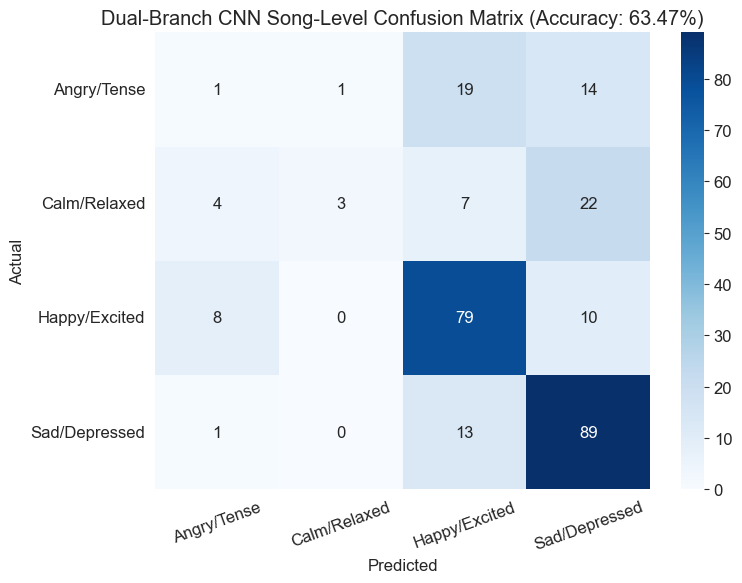


Per-class song-level accuracy:
  Angry/Tense: 2.86% (35 songs)
  Calm/Relaxed: 8.33% (36 songs)
  Happy/Excited: 81.44% (97 songs)
  Sad/Depressed: 86.41% (103 songs)


In [17]:
# ============================================================
# Evaluate on Test Set — dual-branch model, no manual overrides
# ============================================================
def aggregate_song_predictions(crop_probs, crop_labels, crop_song_ids):
    grouped_probs = defaultdict(list)
    grouped_labels = {}

    for song_id, probs, label in zip(crop_song_ids, crop_probs, crop_labels):
        grouped_probs[int(song_id)].append(probs)
        grouped_labels[int(song_id)] = int(label)

    song_ids = []
    y_true_song = []
    y_pred_song = []
    y_prob_song = []

    for song_id in sorted(grouped_probs):
        mean_prob = np.mean(grouped_probs[song_id], axis=0)
        song_ids.append(song_id)
        y_true_song.append(grouped_labels[song_id])
        y_pred_song.append(int(np.argmax(mean_prob)))
        y_prob_song.append(mean_prob)

    return (
        np.asarray(song_ids, dtype=np.int32),
        np.asarray(y_true_song, dtype=np.int32),
        np.asarray(y_pred_song, dtype=np.int32),
        np.asarray(y_prob_song, dtype=np.float32),
    )


def predict_with_tta(model, X_spec, X_arousal, batch_size):
    """Test-time augmentation with dual inputs."""
    variants_spec = [
        X_spec,
        np.roll(X_spec, shift=4, axis=2),
        np.roll(X_spec, shift=-4, axis=2),
    ]

    emotion_list = []
    valence_list = []
    arousal_list = []
    for variant in variants_spec:
        outputs = model.predict(
            {'spec_input': variant, 'arousal_input': X_arousal},
            batch_size=batch_size, verbose=0
        )
        emotion_probs, valence_probs, arousal_probs = unpack_outputs(outputs)
        emotion_list.append(emotion_probs)
        valence_list.append(valence_probs)
        arousal_list.append(arousal_probs)

    return (
        np.mean(emotion_list, axis=0),
        np.mean(valence_list, axis=0),
        np.mean(arousal_list, axis=0),
    )


eval_results = model.evaluate(test_ds, return_dict=True, verbose=0)
emotion_probs, valence_probs, arousal_probs = predict_with_tta(
    model, X_test_crops, X_test_arousal, batch_size=BATCH_SIZE
)
test_crop_probs = blend_quadrant_probs(emotion_probs, valence_probs, arousal_probs)

song_ids_eval, y_true_song, y_pred_song, y_prob_song = aggregate_song_predictions(
    test_crop_probs,
    y_test_emotion,
    test_crop_song_ids,
)

song_acc = accuracy_score(y_true_song, y_pred_song)
song_weighted_f1 = f1_score(y_true_song, y_pred_song, average='weighted', zero_division=0)
song_macro_f1 = f1_score(y_true_song, y_pred_song, average='macro', zero_division=0)

print(f"Crop-level Test Loss: {eval_results['loss']:.4f}")
print(f"Crop-level Emotion Accuracy: {eval_results['emotion_accuracy']:.4f}")
print(f"Crop-level Valence Accuracy: {eval_results['valence_accuracy']:.4f}")
print(f"Crop-level Arousal Accuracy: {eval_results['arousal_accuracy']:.4f}")
print(f"Song-level Test Accuracy (blended + TTA): {song_acc:.4f}")
print(f"Song-level Test Weighted-F1: {song_weighted_f1:.4f}")
print(f"Song-level Test Macro-F1: {song_macro_f1:.4f}\n")

print(f"Thresholds — Valence: {VALENCE_THRESHOLD:.3f}, Arousal: {AROUSAL_THRESHOLD:.3f}")

target_names = le_cnn.classes_
print("\nSong-level Classification Report:")
print(classification_report(y_true_song, y_pred_song, target_names=target_names, zero_division=0))

cm = confusion_matrix(y_true_song, y_pred_song)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    ax=ax,
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Dual-Branch CNN Song-Level Confusion Matrix (Accuracy: {song_acc:.2%})')
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nPer-class song-level accuracy:")
for i, cls in enumerate(target_names):
    mask = y_true_song == i
    if mask.sum() > 0:
        acc = (y_pred_song[mask] == i).sum() / mask.sum()
        print(f"  {cls}: {acc:.2%} ({mask.sum()} songs)")
